# Multivariate GARCH of Equity, Oil, and FX Returns (PROC VARMAX)


## Executive Summary

This notebook fits a **constant conditional correlation (CCC)
multivariate GARCH** to the daily returns of three markets a
diversified book might hold at once — U.S. equities (S&P 500),
crude oil (WTI), and the euro (EUR/USD) — using **PROC VARMAX**.
A GARCH(1,1) is estimated for each series' volatility, and a
single correlation matrix ties the standardized shocks together.

The fit runs on 2,100 daily returns (2016–2024) and shows two
things a single-asset volatility model cannot. First, all three
markets are **highly persistent**: the GARCH persistence
$\alpha+\beta$ sits near 0.98 for each, so calm and turbulent
days arrive in long runs. Second, the **conditional correlations**
are small and uneven — 0.213 between equities and oil, 0.093
between equities and the euro, and 0.047 between oil and the euro
— which says the euro diversifies equity risk far better than oil
does. Every number quoted below is read directly from the output
of the cells that follow.


## Data Sources

| Dataset | Rows | Frequency | Key Variables | Description |
|---|---|---|---|---|
| `returns_d.csv` | 2100 | Daily (trading days) | `date`, `sp500`, `wti`, `eurusd` | Daily percent log returns of the S&P 500 index (FRED `SP500`), WTI crude spot price (`DCOILWTICO`), and the US-dollar-per-euro rate (`DEXUSEU`), 2016-07-12 through 2024-12-31. Only sessions on which all three markets quoted are kept. Committed alongside the notebook so the analysis is self-contained and reproducible. |

The same series can be pulled live from FRED with a three-line
`SASEFRED` LIBNAME; this notebook reads the committed snapshot so
it runs offline and returns identical numbers every time. The
full 2,100-row sample is used throughout.


## Step 1 - Load the daily return series

Read the committed returns; `PROC IMPORT` recognizes the `date`
column as a calendar date, ready to plot against. A quick
`PROC MEANS` confirms the scale of each market: returns are
centered near zero, but their variances differ by almost two
orders of magnitude — oil is far wilder day to day than the euro.
The S&P 500 return series plotted over time shows the hallmark of
volatility that a GARCH model is built to capture: quiet
stretches broken by bursts of large moves that cluster together,
most dramatically in early 2020.


                                                  The MEANS Procedure

 Variable          N           Mean    Variance
 ----------------------------------------------
 sp500          2100          0.051       1.318
 wti            2100          0.057       9.934
 eurusd         2100         -0.003       0.201
 ----------------------------------------------




NOTE: PROC IMPORT datafile=returns_d.csv out=returns

NOTE: Imported 2100 rows from returns_d.csv.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=returns

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


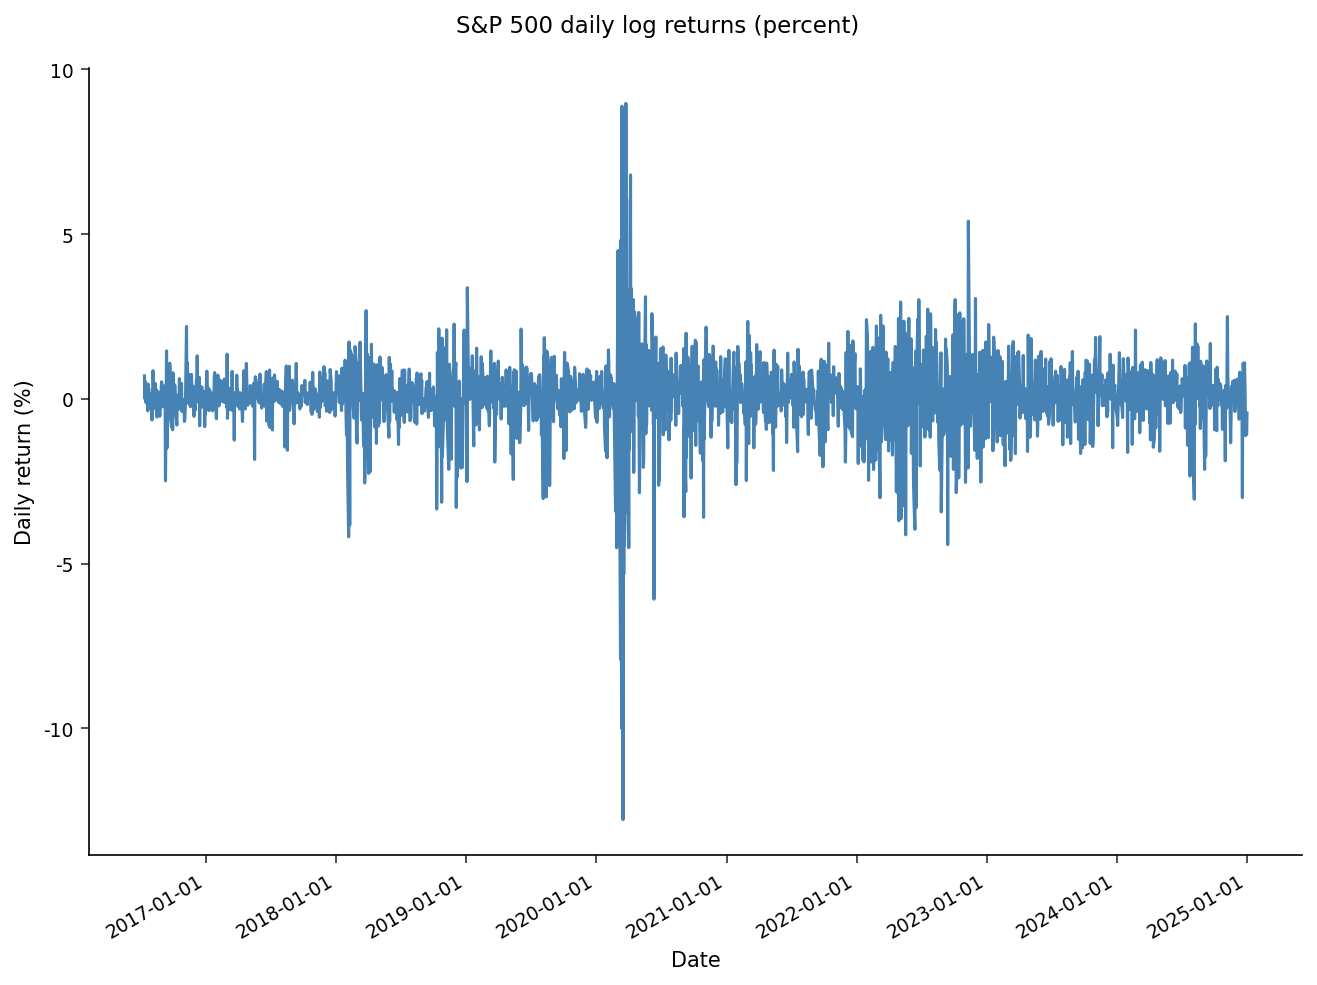

In [1]:
proc import datafile="returns_d.csv" out=returns dbms=csv replace;
    getnames=yes;
run;

proc means data=returns n mean var maxdec=3;
    var sp500 wti eurusd;
run;

proc sgplot data=returns;
    series x=date y=sp500 / lineattrs=(color=steelblue);
    title "S&P 500 daily log returns (percent)";
    xaxis label="Date";
    yaxis label="Daily return (%)";
run;

The variances confirm the ordering: about 1.32 for the S&P, 9.93
for oil, and just 0.20 for the euro. The return plot makes the
clustering visible — the calm of 2017 gives way to sharp,
bunched swings around the 2020 COVID crash, exactly the
time-varying volatility a constant-variance model would miss.


## Step 2 - Fit the CCC multivariate GARCH(1,1)

The `MODEL` statement sets a light mean model for the three
returns; the `GARCH` statement does the real work, fitting a
GARCH(1,1) to each return's residuals and estimating the constant
correlation across the standardized shocks. `FORM=CCC` selects
the constant-conditional-correlation structure, and `OUTHT=`
saves the fitted conditional variances for every trading day so
we can plot them next.


In [2]:
proc varmax data=returns;
    model sp500 wti eurusd;
    garch p=1 q=1 form=ccc outht=condvar;
run;


                                                  The VARMAX Procedure                                                  

Model Type: VAR(1)
Number of Observations: 2100
Dependent Variables: sp500 wti eurusd
AR Order (p): 1
MA Order (q): 0

Parameter Estimates
Parameter                Estimate    Std Error      t Value     Pr > |t|
---------                --------    ---------      -------     --------
L1.sp500->sp500         -0.148366     0.022092        -6.72       0.0000
L1.wti->sp500           -0.000721     0.007988        -0.09       0.9281
L1.eurusd->sp500         0.008729     0.055678         0.16       0.8754
L1.sp500->wti            0.042786     0.061220         0.70       0.4846
L1.wti->wti             -0.044077     0.022135        -1.99       0.0465
L1.eurusd->wti          -0.235313     0.154291        -1.53       0.1272
L1.sp500->eurusd         0.057439     0.008636         6.65       0.0000
L1.wti->eurusd           0.001380     0.003122         0.44       0.6585
L1.eurus


NOTE: PROC VARMAX data=returns

NOTE: Using Python (statsmodels VAR/VARMAX) for VARMAX estimation
NOTE: OUTHT= dataset condvar has 2099 observations


Read the heteroscedasticity parameters one block per series —
`GCHC` is the constant $\omega$, `ACH1` the ARCH term $\alpha$,
and `GCH1` the GARCH term $\beta$:

| Series | $\omega$ | $\alpha$ | $\beta$ | $\alpha+\beta$ |
|---|---:|---:|---:|---:|
| S&P 500 | 0.036 | 0.197 | 0.780 | 0.977 |
| WTI crude | 0.216 | 0.122 | 0.846 | 0.968 |
| EUR/USD | 0.003 | 0.046 | 0.937 | 0.983 |

The persistence $\alpha+\beta$ is near 0.98 for all three, so a
volatility shock decays slowly and turbulent days cluster into
turbulent weeks. The mix differs: the S&P's larger $\alpha$
(0.197) means its variance reacts sharply to a big move, while
the euro leans on its $\beta$ (0.937), drifting more smoothly.

The constant conditional correlation matrix printed alongside
reports how the standardized shocks move together:

| | S&P 500 | WTI | EUR/USD |
|---|---:|---:|---:|
| **S&P 500** | 1.000 | 0.213 | 0.093 |
| **WTI** | 0.213 | 1.000 | 0.047 |
| **EUR/USD** | 0.093 | 0.047 | 1.000 |

Equities and oil share the strongest link (0.213); the euro is
nearly independent of both.


## Step 3 - Track conditional volatility over time

`OUTHT=` wrote the fitted conditional **variance** of each series
for every trading day. Take its square root to get the
conditional **volatility** (a daily standard deviation, in
percent), attach the calendar dates by position, and plot each
series. These are the diagonal of $H_t$ moving through time — the
part of portfolio risk that flares in a crisis and settles in
calm markets.


                                                  The MEANS Procedure

 Variable            N        Mean
 ---------------------------------
 sp500_vol        2099       0.975
 wti_vol          2099       2.480
 eurusd_vol       2099       0.435
 ---------------------------------




NOTE: DATA dates


NOTE: Read 2099 rows from returns.
NOTE: Wrote dates (2099 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds
NOTE: DATA vol

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=vol

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=vol

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: PROC SGPLOT data=vol

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg


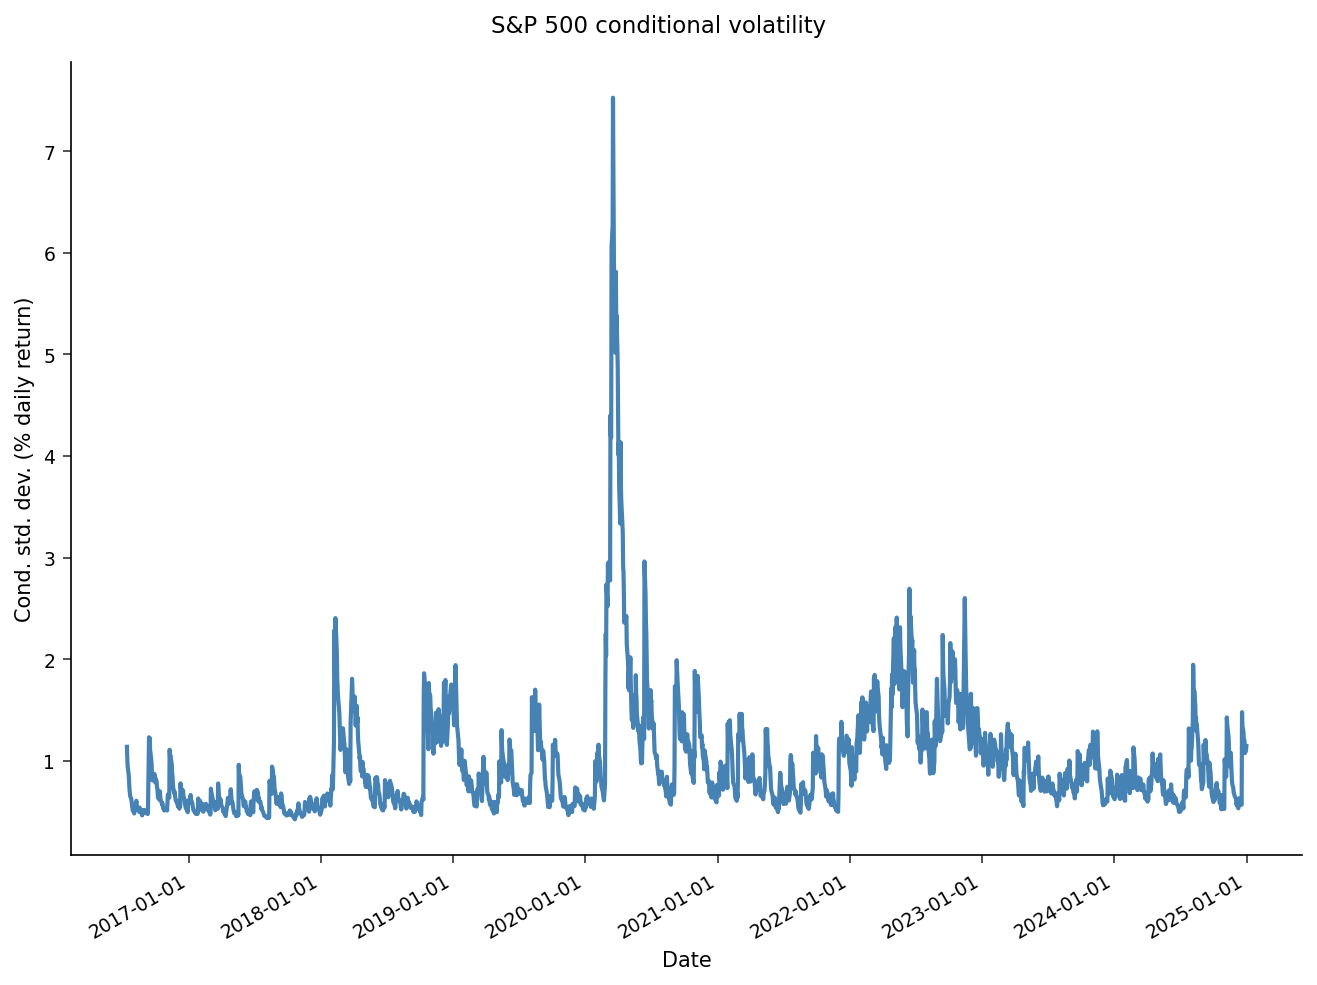

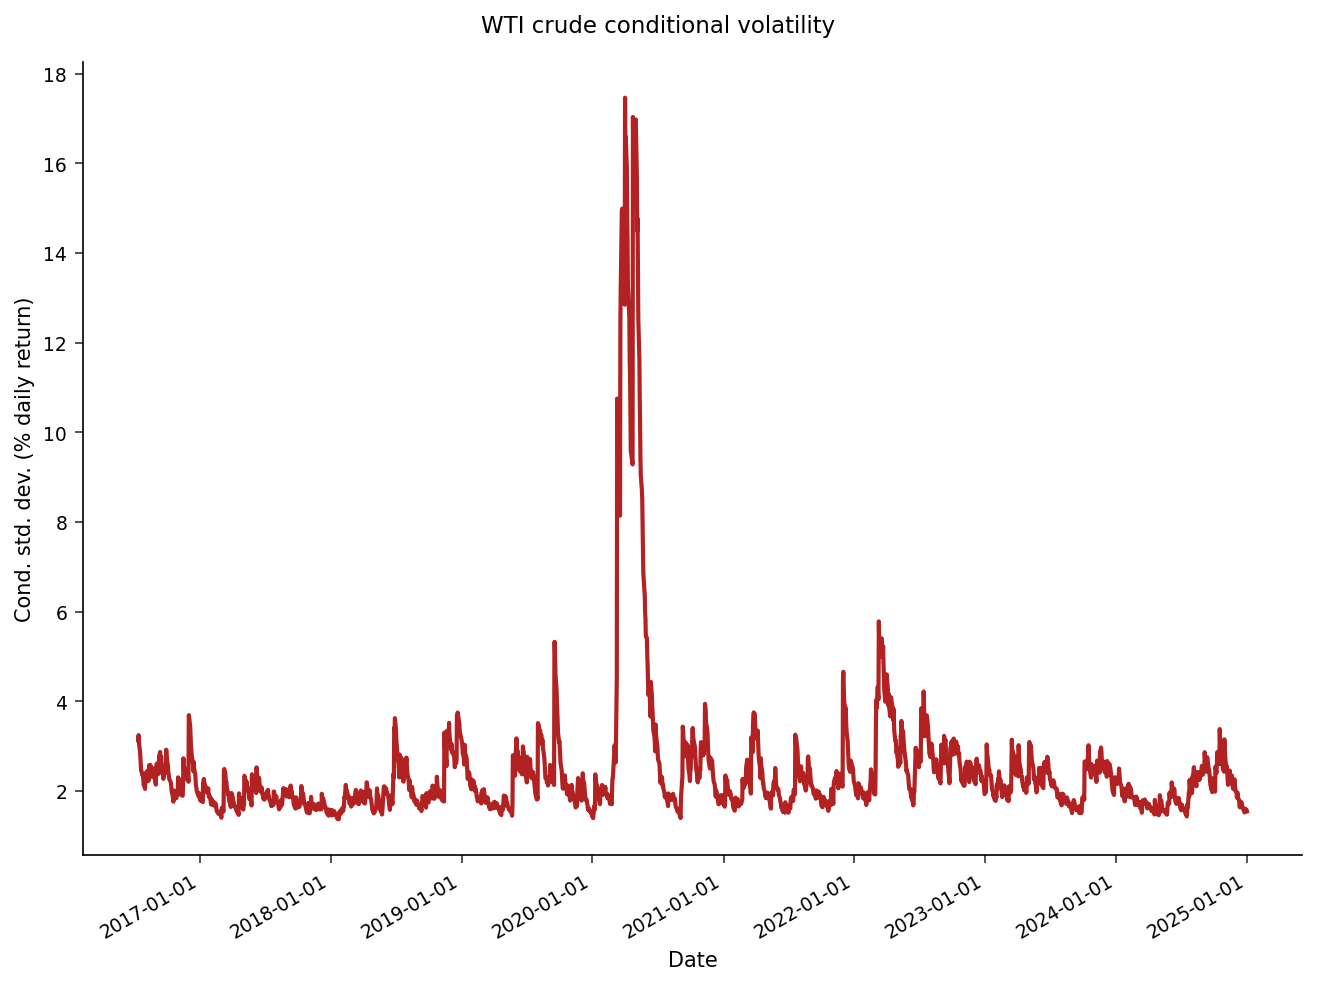

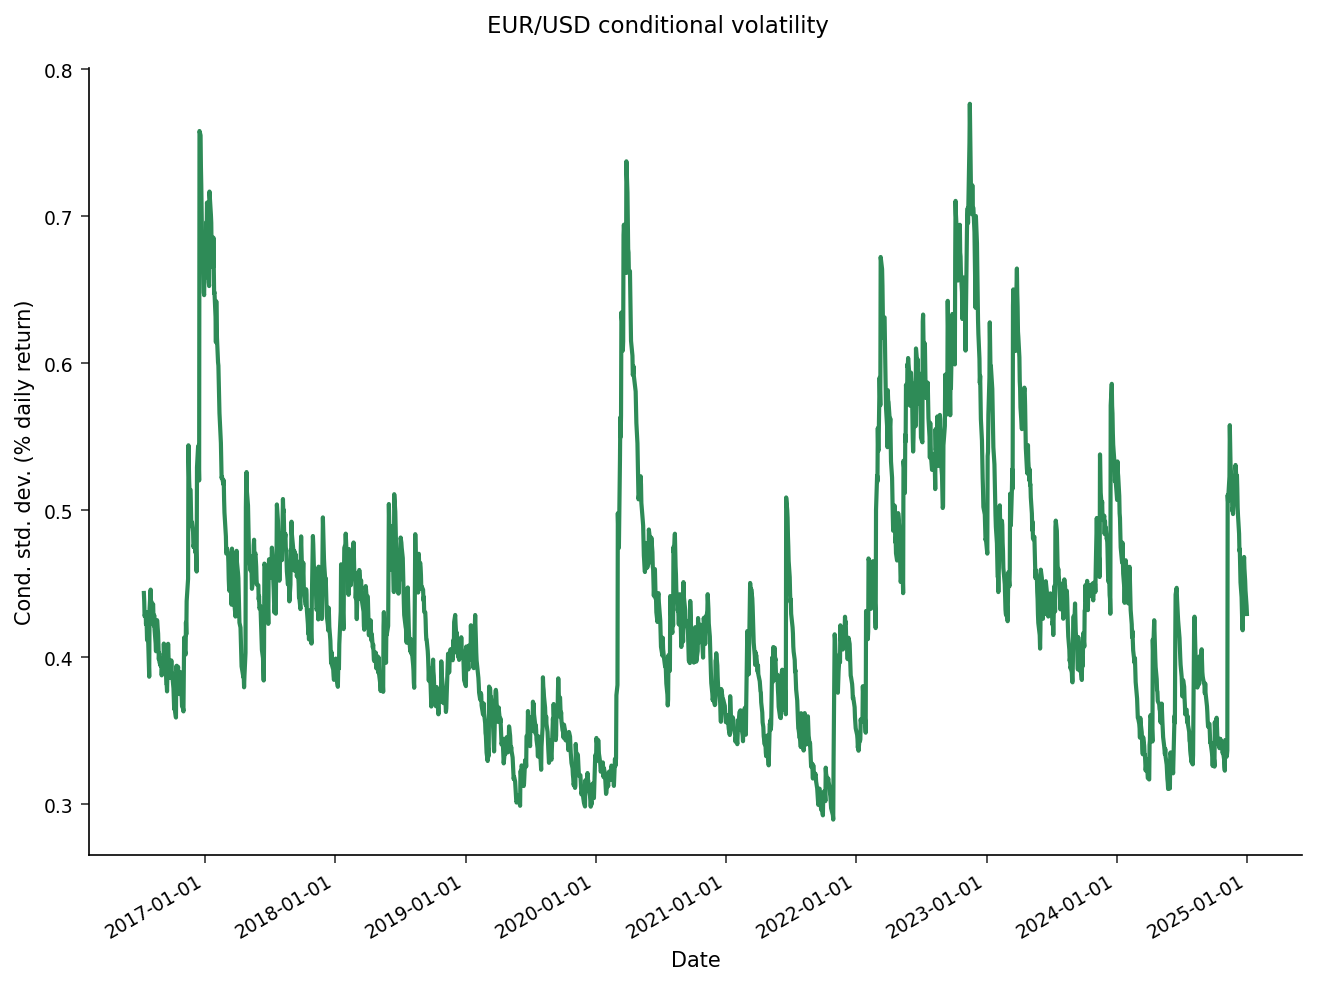

In [3]:
data dates;
    set returns(firstobs=2 keep=date);
run;

data vol;
    merge condvar dates;
    sp500_vol  = sqrt(sp500);
    wti_vol    = sqrt(wti);
    eurusd_vol = sqrt(eurusd);
run;

proc means data=vol n mean maxdec=3;
    var sp500_vol wti_vol eurusd_vol;
run;

proc sgplot data=vol;
    series x=date y=sp500_vol / lineattrs=(color=steelblue thickness=2);
    title "S&P 500 conditional volatility";
    xaxis label="Date";
    yaxis label="Cond. std. dev. (% daily return)";
run;

proc sgplot data=vol;
    series x=date y=wti_vol / lineattrs=(color=firebrick thickness=2);
    title "WTI crude conditional volatility";
    xaxis label="Date";
    yaxis label="Cond. std. dev. (% daily return)";
run;

proc sgplot data=vol;
    series x=date y=eurusd_vol / lineattrs=(color=seagreen thickness=2);
    title "EUR/USD conditional volatility";
    xaxis label="Date";
    yaxis label="Cond. std. dev. (% daily return)";
run;

Average conditional volatility is about 0.98% a day for the S&P,
2.48% for oil, and 0.44% for the euro — the same wide spread the
variances showed, now resolved day by day. Each series is calm
through 2017–2019, then spikes in early 2020: equity volatility
jumps to about 7.5% at the COVID crash, and oil's runs off the
chart near 17.5% in April 2020 when WTI briefly collapsed toward
zero. The euro stays on a far lower scale throughout — its 2020
spike is real but modest (about 0.7%), and its largest swings
come later, in 2022–2023, driven by its own story of ECB
tightening and the European energy crisis rather than by the
equity-and-oil moves. Low *absolute* volatility is only half of
why the euro diversifies the book; the other half is that its
shocks barely correlate with the other two, which the next
section reads off the correlation matrix.


## Interpreting the results

- **Volatility clusters and persists.** Every series has a GARCH
  persistence $\alpha+\beta$ near 0.98 (0.977 for the S&P, 0.968
  for oil, 0.983 for the euro), so a shock to volatility fades
  over weeks, not days — the statistical signature of the calm
  and crisis regimes visible in the plots.
- **The markets react differently.** The S&P's higher ARCH term
  ($\alpha=0.197$) makes its variance jump on a big day; the euro
  leans on its GARCH term ($\beta=0.937$) for a smoother path.
- **Correlations decide diversification.** The conditional
  correlations — 0.213 (equities–oil), 0.093 (equities–euro),
  0.047 (oil–euro) — are what a single-asset volatility model
  cannot see. A book that offsets equity risk with the euro is
  far better diversified than one that offsets it with oil,
  because the euro's shocks barely move with equities'.
- **This is the input risk models need.** CCC estimates the whole
  conditional covariance $H_t = D_t R D_t$ — time-varying
  volatilities in $D_t$, a stable correlation matrix in $R$ —
  which is exactly what a portfolio value-at-risk or capital
  figure is computed from.

The same analysis is locked in as Jenner regression test `71050`,
which checks these GARCH parameters and correlations against an
independent R reference (`MTS::dccPre`) within tolerance.
